# 다음 영화 리뷰의 키워드 분석

1. 데이터 준비( Collection )
2. 텍스트 전처리 (토큰화, 불용어 제거)
3. 빈도수 분석( Counter )

* 시각화 1: 수평 막대그래프
* 시각화 2: 워드 클라우드
  

In [1]:
# 데이터 준비 ( 로딩 ) 
data_filename = '../data/daum_movie_review.csv'
input_filename = 'daum_movie_review.csv'

import pandas as pd
movie_df = pd.read_csv(data_filename)

# movie_df.info()
# movie_df.tail()

review_list = list(movie_df.review)
review_list[:10]

['돈 들인건 티가 나지만 보는 내내 하품만',
 '몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.',
 '이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 모은 것까지는 좋았으나 이걸 모두 한 그릇에 섞어버린 듯한 느낌... 그래도 다음 작품을 기대하게 만든다...',
 '이 정도면 볼만하다고 할 수 있음!',
 '재미있다',
 '나는 재밌게 봄',
 '0.5점은 줄 수 없냐?',
 '헐..다 죽었어....나중에 앤트맨 보다가도 깜놀...',
 '충격 결말',
 '응집력']

In [2]:
# 텍스트 전처리
from konlpy.tag import Okt

tagger = Okt()

# 리뷰 리스트에서 리뷰를 하나씩 꺼내서 tagger.pos로 분석
pos_list = [ pos_tuple for review in review_list for pos_tuple in tagger.pos(review)]

print(f'전체 형태소 수 : {len(pos_list):,}')
print(f'형태소 맛보기 : {pos_list[:10]}')

# 품사 태깅 -> Noun/명사, Verb/동사, Adjective/형용사 토큰만 필터링
my_tags = ['Noun', 'Verb', 'Adjective']
my_tokens = [word for word, tag in pos_list if tag in my_tags]
print(f'사용할 토큰 수 : {len(my_tokens):,}')

# 불용어 삭제 
my_stopwords =['된', '입', '제', '할', '정', '수', '관', '영화', '것', '정말', '이', '더', '진짜', '잘',
               '하는', '보고', '점', '좀', '생각','그', '입니다', '그냥', '정도', '돈', '볼', '꼭', '있는',
               '영화','내','말','본', '왜', '때', '보는', '듯', '나', '합니다', '편', '봤는데', '느낌', '이런',' 다시',
              '함', '뭐', '안', '거', '봤습니다', '한번', '한', '넘', '같은', '안', '해서', '같은']
my_new_tokens = [ token for token in my_tokens if token not in my_stopwords ]

print(f'불용어 제거 후 토큰 수 : {len(my_new_tokens):,}')

my_tokens = my_new_tokens

전체 형태소 수 : 305,916
형태소 맛보기 : [('돈', 'Noun'), ('들인건', 'Verb'), ('티', 'Noun'), ('가', 'Josa'), ('나', 'Noun'), ('지만', 'Josa'), ('보는', 'Verb'), ('내내', 'Noun'), ('하품', 'Noun'), ('만', 'Josa')]
사용할 토큰 수 : 194,792
불용어 제거 후 토큰 수 : 165,483


In [3]:
# 빈도수 분석
from collections import Counter

const_counter = Counter(my_tokens)

# 고유 단어 수 확인
print(f'고유 단어 종류: {len(const_counter):,}개')

# 빈도수 상위 20개 단어의 (단어, 빈도수) 튜플 리스트 추출
top_20_keywords = const_counter.most_common(20)

# 추출된 상위 20개 키워드 확인
print("상위 20개 키워드:")
print(top_20_keywords)


고유 단어 종류: 26,462개
상위 20개 키워드:
[('연기', 1293), ('감동', 1223), ('배우', 847), ('사람', 819), ('스토리', 815), ('눈물', 737), ('최고', 682), ('재미', 641), ('마지막', 612), ('시간', 596), ('마동석', 556), ('광주', 530), ('윤계상', 517), ('기대', 516), ('내용', 494), ('장면', 438), ('원작', 422), ('평점', 407), ('신파', 387), ('좋은', 377)]


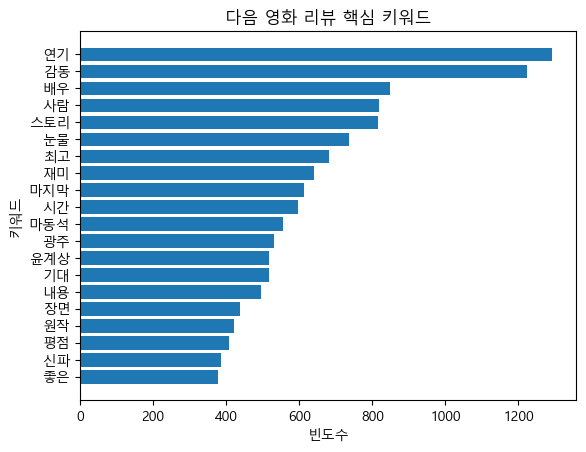

In [4]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 한글 폰트 path 지정
font_path = "c:/Windows/fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 단어 이름과 빈도수 데이터 분리 추출
x_list = [word for word, count in top_20_keywords]
y_list = [count for word, count in top_20_keywords]

plt.barh(x_list[::-1], y_list[::-1])

plt.title('다음 영화 리뷰 핵심 키워드')
plt.xlabel('빈도수')
plt.ylabel('키워드')

result_filename = '../result/' + input_filename.replace('.csv', '_graph.jpg')
plt.savefig(result_filename, bbox_inches='tight') # 찾아보니 글자 잘리지 않게 여백 조정해주는 것

In [5]:
from wordcloud import WordCloud

const_wc = WordCloud(
    font_path = font_path,
    background_color = 'ivory',
    width=800,
    height=600,
    max_words=50
)

const_wc = const_wc.generate_from_frequencies(const_counter)

result_filename = '../result/' + input_filename.replace('.csv', '_wordcloud.jpg')
const_wc.to_file(result_filename)